# Setup

In [1]:
import ast
import os
import random
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "base_class.py").exists():
    ROOT = ROOT.parent

ALGO_DIR = ROOT / "experiments" / "nvtai"
DATA_DIR = ROOT / "dataset" / "artificial data"

sys.path.append(str(ROOT))
sys.path.append(str(ALGO_DIR))

PATH_FILES = sorted(
    DATA_DIR.glob("dna_*.txt"),
    key=lambda p: int(p.stem.split("_")[1])
)

for path in PATH_FILES:
    print(path)

/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_10.txt
/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_20.txt
/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_40.txt
/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_80.txt
/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_160.txt
/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_320.txt
/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_640.txt
/home/tai/Coder/year3_2/DAA/dna-matching/dataset/artificial data/dna_1280.txt


In [2]:
def load_dataset(path_files):
    records = []

    for path in path_files:
        with open(path, "r") as f:
            for sample_id, line in enumerate(f):
                text, pattern, k, expected = line.strip().split(" ", maxsplit=3)
                records.append({
                    "file": path.name,
                    "sample_id": sample_id,
                    "text": text,
                    "pattern": pattern,
                    "k": int(k),
                    "expected": ast.literal_eval(expected),
                })

    return records


records = load_dataset(PATH_FILES)
print("Total samples:", len(records))

Total samples: 80


# Experiment

In [3]:
from brute_force import BruteForceKMismatches
from suffix_array import SuffixArrayWithCandidateVerification

algorithms = [
    BruteForceKMismatches(),
    SuffixArrayWithCandidateVerification(),
]

In [4]:
def valid(pred, expected):
    return sorted(pred) == sorted(expected)


def test_algorithm(algo, records):
    rows = []

    for row in records:
        eval_result = algo.evaluate(row["text"], row["pattern"], row["k"])
        pred = eval_result["matches"]

        rows.append({
            "file": row["file"],
            "sample_id": row["sample_id"],
            "algorithm": algo.name,
            "input_size": len(row["text"]),
            "text_len": len(row["text"]),
            "pattern_len": len(row["pattern"]),
            "k": row["k"],
            "runtime_sec": eval_result["runtime_sec"],
            "num_expected": len(row["expected"]),
            "num_pred": eval_result["num_matches"],
            "valid": valid(pred, row["expected"]),
            "expected": row["expected"],
            "pred": pred,
        })

    return rows

In [5]:
import pandas as pd

all_rows = []
for algo in algorithms:
    all_rows.extend(test_algorithm(algo, records))

df_all = pd.DataFrame(all_rows)
df_all.head()

,file,sample_id,algorithm,input_size,text_len,pattern_len,k,runtime_sec,num_expected,num_pred,valid,expected,pred
0,dna_10.txt,0,Brute Force with k mismatches,10,10,3,0,0.000012,1,1,True,[1],[1]
1,dna_10.txt,1,Brute Force with k mismatches,10,10,3,0,0.000005,1,1,True,[3],[3]
2,dna_10.txt,2,Brute Force with k mismatches,10,10,3,0,0.000004,1,1,True,[6],[6]
3,dna_10.txt,3,Brute Force with k mismatches,10,10,3,1,0.000004,2,2,True,"[2, 3]","[2, 3]"
4,dna_10.txt,4,Brute Force with k mismatches,10,10,3,0,0.000003,1,1,True,[1],[1]


In [6]:
summary = df_all.groupby(["algorithm", "input_size"]).agg(
    num_samples=("sample_id", "count"),
    num_correct=("valid", "sum"),
    avg_runtime_sec=("runtime_sec", "mean"),
    median_runtime_sec=("runtime_sec", "median"),
    min_runtime_sec=("runtime_sec", "min"),
    max_runtime_sec=("runtime_sec", "max"),
    total_runtime_sec=("runtime_sec", "sum"),
    avg_pattern_len=("pattern_len", "mean"),
    avg_k=("k", "mean"),
).reset_index()

summary["num_wrong"] = summary["num_samples"] - summary["num_correct"]
summary["accuracy"] = summary["num_correct"] / summary["num_samples"]

summary

,algorithm,input_size,num_samples,num_correct,avg_runtime_sec,median_runtime_sec,min_runtime_sec,max_runtime_sec,total_runtime_sec,avg_pattern_len,avg_k,num_wrong,accuracy
0,Brute Force with k mismatches,10,10,10,0.000005,0.000004,0.000003,0.000012,0.000047,3.0,0.3,0,1.0
1,Brute Force with k mismatches,20,10,10,0.000007,0.000007,0.000006,0.000009,0.000073,3.0,0.3,0,1.0
2,Brute Force with k mismatches,40,10,10,0.000014,0.000013,0.000012,0.000018,0.000137,4.0,0.2,0,1.0
3,Brute Force with k mismatches,80,10,10,0.000031,0.000029,0.000024,0.000047,0.000314,8.0,0.7,0,1.0
4,Brute Force with k mismatches,160,10,10,0.000131,0.000134,0.000068,0.000191,0.001311,16.0,3.5,0,1.0
5,Brute Force with k mismatches,320,10,10,0.000435,0.000424,0.000186,0.000736,0.004351,32.0,6.5,0,1.0
6,Brute Force with k mismatches,640,10,10,0.001849,0.002064,0.000369,0.002934,0.018485,64.0,11.9,0,1.0
7,Brute Force with k mismatches,1280,10,10,0.003684,0.003949,0.001485,0.006655,0.036845,128.0,25.7,0,1.0
8,Suffix Array with Candidate Verification,10,10,10,0.000011,0.000008,0.000005,0.000029,0.000109,3.0,0.3,0,1.0
9,Suffix Array with Candidate Verification,20,10,10,0.000010,0.000008,0.000007,0.000017,0.000098,3.0,0.3,0,1.0


In [7]:
wrong_df = df_all[df_all["valid"] == False]
print("So mau sai:", len(wrong_df))
wrong_df[["file", "sample_id", "algorithm", "pattern_len", "k", "expected", "pred"]].head(10)

So mau sai: 0


,file,sample_id,algorithm,pattern_len,k,expected,pred


In [8]:
def show_random_samples(df, seed=42, n_samples=10):
    random.seed(seed)
    indices = random.sample(list(df.index), min(n_samples, len(df)))

    for idx, row_id in enumerate(indices, start=1):
        row = df.loc[row_id]
        print(f"Sample {idx}")
        print("Algorithm  :", row["algorithm"])
        print("File       :", row["file"])
        print("Input size :", row["input_size"])
        print("Pattern len:", row["pattern_len"])
        print("k          :", row["k"])
        print("Expected   :", row["expected"])
        print("Predicted  :", row["pred"])
        print("Runtime    :", row["runtime_sec"])
        print("Valid      :", row["valid"])
        print("-" * 80)


show_random_samples(df_all, seed=42, n_samples=10)

Sample 1
Algorithm  : Brute Force with k mismatches
File       : dna_40.txt
Input size : 40
Pattern len: 4
k          : 0
Expected   : [27]
Predicted  : [27]
Runtime    : 1.2507000064942986e-05
Valid      : True
--------------------------------------------------------------------------------
Sample 2
Algorithm  : Brute Force with k mismatches
File       : dna_10.txt
Input size : 10
Pattern len: 3
k          : 1
Expected   : [5, 7]
Predicted  : [5, 7]
Runtime    : 4.0410000110568944e-06
Valid      : True
--------------------------------------------------------------------------------
Sample 3
Algorithm  : Brute Force with k mismatches
File       : dna_1280.txt
Input size : 1280
Pattern len: 128
k          : 24
Expected   : [422]
Predicted  : [422]
Runtime    : 0.006312222999895312
Valid      : True
--------------------------------------------------------------------------------
Sample 4
Algorithm  : Brute Force with k mismatches
File       : dna_640.txt
Input size : 640
Pattern len: 64


# Visualization

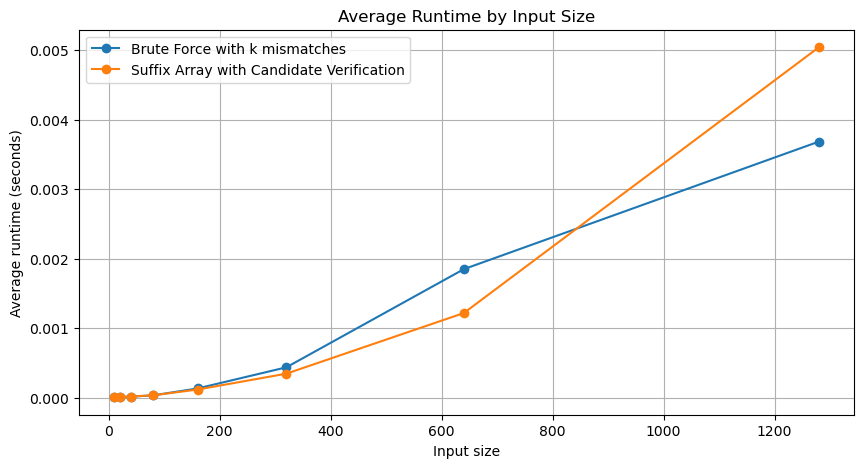

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for algo_name, group in summary.groupby("algorithm"):
    plt.plot(
        group["input_size"],
        group["avg_runtime_sec"],
        marker="o",
        label=algo_name,
    )

plt.xlabel("Input size")
plt.ylabel("Average runtime (seconds)")
plt.title("Average Runtime by Input Size")
plt.grid(True)
plt.legend()
plt.show()

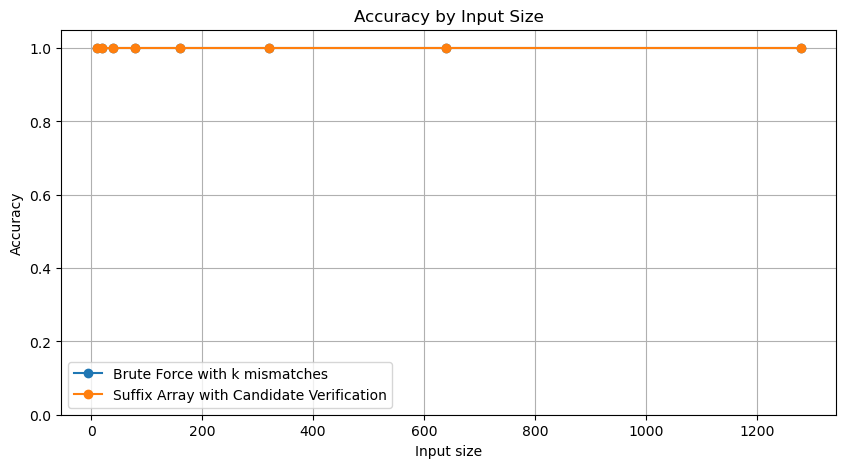

In [10]:
plt.figure(figsize=(10, 5))

for algo_name, group in summary.groupby("algorithm"):
    plt.plot(
        group["input_size"],
        group["accuracy"],
        marker="o",
        label=algo_name,
    )

plt.xlabel("Input size")
plt.ylabel("Accuracy")
plt.title("Accuracy by Input Size")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()